# 14 — Rollover (trailing take-profit) exit

The causal alternative to nb13's time-cut. The time-cut ("still red at minute
240-N -> cut") was refuted: being underwater early is normal for a reversion
trade, so cutting losers ejects future winners. **Rollover looks at our PROFIT
instead.** Track the best favorable MTM since entry; once the trade has been green
(peak > 0), exit on the first bar where MTM falls back by `g` from that peak — the
move in our favor has rolled over, lock it in instead of round-tripping to the
240-min horizon. `g=hold` = no rollover = baseline (nb12 / nb13 N=0).

Unlike the time-cut, rollover only TAKES PROFIT (it never cuts a never-green
loser). Catastrophe stop (pump 30% / dump 20%) still on. Built from raw OHLCV
(`_build_rollover_sweep.py`), faithful to nb12/13 in entries/scale-in/costs.

**The empirical question (measure first):** does the reversion peak well before
minute 240 and then decay (rollover captures the peak) or grow toward the horizon
(rollover exits early on noise and kills edge)? `tpeak` answers it.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show
import numpy as np, pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

PUMP = pd.read_parquet("_out/pump_rollover.parquet")
DUMP = pd.read_parquet("_out/dump_rollover.parquet")
GIVEBACKS=[0.005,0.01,0.02,0.03,0.05,0.08,np.inf]
PF=["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
DF=["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]
def naive(s):
    s=pd.to_datetime(s); return s.dt.tz_localize(None) if s.dt.tz is not None else s
for D in (PUMP,DUMP):
    D["entry"]=naive(D["entry"])
    for i in range(len(GIVEBACKS)): D[f"exit{i}"]=naive(D[f"exit{i}"])
def glab(g): return "hold" if not np.isfinite(g) else f"{g:.1%}"
print(f"pump {len(PUMP)} events; dump {len(DUMP)} events")

pump 12034 events; dump 4286 events


## Step 1 — when does the reversion peak? (does rollover even make sense?)

If the favorable MTM peaks late (near 240) rollover can only hurt. If it peaks
early and decays, there's profit to capture. Look at the distribution of `tpeak`
(minute of peak favorable MTM, out of 240) and how much of the peak survives to
the horizon (mean final vs mean peak).

In [2]:
for D,nm in ((PUMP,"pump"),(DUMP,"dump")):
    hold=D[f"pnl{len(GIVEBACKS)-1}"]   # g=hold final pnl
    print(f"{nm}: tpeak (min of 240)  median {D.tpeak.median():.0f}  mean {D.tpeak.mean():.0f}  "
          f"q25 {D.tpeak.quantile(.25):.0f}  q75 {D.tpeak.quantile(.75):.0f}")
    print(f"      peak favorable MTM  mean {D.peakmtm.mean()*100:+.2f}%  median {D.peakmtm.median()*100:+.2f}%")
    print(f"      final (hold)        mean {hold.mean()*100:+.2f}%  -> keeps {hold.mean()/D.peakmtm.mean()*100:.0f}% of the avg peak")
    print(f"      peaks in first half (<120m): {(D.tpeak<120).mean()*100:.0f}%   in last quarter (>180m): {(D.tpeak>180).mean()*100:.0f}%")

pump: tpeak (min of 240)  median 73  mean 96  q25 17  q75 176
      peak favorable MTM  mean +4.94%  median +4.13%
      final (hold)        mean -0.20%  -> keeps -4% of the avg peak
      peaks in first half (<120m): 62%   in last quarter (>180m): 23%
dump: tpeak (min of 240)  median 105  mean 115  q25 31  q75 199
      peak favorable MTM  mean +10.08%  median +6.97%
      final (hold)        mean +4.95%  -> keeps 49% of the avg peak
      peaks in first half (<120m): 54%   in last quarter (>180m): 31%


## Step 2 — per-trade effect of the rollover giveback (raw, before classifier)

In [3]:
def pertrade(D, nm):
    rows=[]
    for i,g in enumerate(GIVEBACKS):
        p=D[f"pnl{i}"]
        rows.append(dict(stream=nm, giveback=glab(g), mean=p.mean()*100, median=p.median()*100,
                         win=(p>0).mean()*100, std=p.std()*100, mstd=p.mean()/p.std(),
                         worst=p.min()*100, fired=(D[f"exit{i}"]<D[f"exit{len(GIVEBACKS)-1}"]).mean()*100))
    return pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
print(pertrade(PUMP,"pump").to_string(index=False)); print()
print(pertrade(DUMP,"dump").to_string(index=False))

stream giveback   mean  median    win   std   mstd   worst  fired
  pump     0.5%  0.247   0.108 53.457 2.533  0.098 -34.730 96.751
  pump     1.0%  0.248   0.016 50.374 2.768  0.090 -34.730 96.551
  pump     2.0%  0.305  -0.188 47.349 3.433  0.089 -34.730 92.222
  pump     3.0%  0.223  -0.427 45.139 3.968  0.056 -34.730 82.059
  pump     5.0%  0.153  -0.560 45.737 4.947  0.031 -34.730 57.321
  pump     8.0% -0.039  -0.101 49.302 5.790 -0.007 -34.730 33.131
  pump     hold -0.197   0.509 53.382 7.359 -0.027 -38.501  0.000

stream giveback  mean  median    win    std  mstd   worst  fired
  dump     0.5% 2.736   1.584 75.875  5.620 0.487 -23.724 98.273
  dump     1.0% 2.827   1.646 74.195  5.756 0.491 -23.724 98.110
  dump     2.0% 3.014   1.644 70.485  6.363 0.474 -23.724 91.391
  dump     3.0% 3.100   1.688 66.426  7.031 0.441 -23.724 80.658
  dump     5.0% 3.466   2.351 64.512  8.241 0.421 -23.724 58.563
  dump     8.0% 3.994   3.285 67.079  9.292 0.430 -23.724 34.041
  dump     hold 

## Step 3 — through the portfolio engine (WF-filtered, $1k @2%, idealized + capacity)

In [4]:
def wf_filter(df, feats, label):
    pred=np.full(len(df),np.nan); cuts=[int(len(df)*q) for q in (0.40,0.55,0.70,0.85,1.0)]; prev=cuts[0]
    for cut in cuts[1:]:
        tr=df.iloc[:prev]
        m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,
            l2_regularization=1.0,min_samples_leaf=50,random_state=0).fit(tr[feats],tr[label])
        pred[prev:cut]=m.predict(df.iloc[prev:cut][feats]); prev=cut
    return df[(pred>0)|np.isnan(pred)]

def engine(df, f=0.02, n_slots=50, reserve=0.10, start=1000.0, cap_frac=None, cap_minutes=30, impact=True):
    df=df.sort_values("entry").reset_index(drop=True)
    eq=start; cash=eq; openp=[]; rec=[]; capped=0
    ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values; liqs=df.liq.values
    for i in range(len(df)):
        now=ents[i]; still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still; rec.append((now,eq))
        if len(openp)>=n_slots: continue
        want=f*eq; avail=eq*(1-reserve)-sum(no for _,no,_ in openp); no=min(want,max(0,avail),cash)
        if cap_frac is not None:
            cap=cap_frac*liqs[i]*cap_minutes
            if no>cap: capped+=1
            no=min(no,cap)
        if no<=0: continue
        pl=pnls[i]
        if impact and cap_frac is not None:
            sz=no/(liqs[i]*cap_minutes+1e-9); pl-=min(0.02,0.5*sz*sz)
        cash-=no; openp.append((exs[i],no,pl))
    for (_,no,pl) in openp: eq+=no*pl
    s=pd.Series([e for _,e in rec], index=pd.to_datetime([t for t,_ in rec]))
    daily=s.resample("D").last().ffill(); r=daily.pct_change().dropna()
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    dd=(daily/daily.cummax()-1).min()
    return dict(final=eq, sharpe=sh, maxdd=dd, capped=capped)

rows=[]
for i,g in enumerate(GIVEBACKS):
    pk=wf_filter(PUMP.assign(pnl=PUMP[f"pnl{i}"], exit_ts=PUMP[f"exit{i}"]), PF, "pnl")
    dk=wf_filter(DUMP.assign(pnl=DUMP[f"pnl{i}"], exit_ts=DUMP[f"exit{i}"]), DF, "pnl")
    comb=pd.concat([pk[["sym","entry","exit_ts","pnl","liq"]],
                    dk[["sym","entry","exit_ts","pnl","liq"]]]).reset_index(drop=True)
    hold=((comb.exit_ts-comb.entry).dt.total_seconds()/60).mean()
    idl=engine(comb,0.02); cap=engine(comb,0.02,cap_frac=0.10)
    rows.append(dict(giveback=glab(g), hold_min=hold,
        ideal_S=idl["sharpe"], ideal_DD=idl["maxdd"]*100, ideal_fin=idl["final"],
        cap_S=cap["sharpe"], cap_DD=cap["maxdd"]*100, cap_fin=cap["final"]))
R=pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(R.to_string(index=False))

giveback  hold_min  ideal_S  ideal_DD  ideal_fin  cap_S  cap_DD  cap_fin
    0.5%     21.02     3.08     -8.20   5,103.17   3.02   -8.23 4,809.00
    1.0%     28.24     3.41     -7.96   5,461.52   3.32   -7.96 5,138.47
    2.0%     59.31     3.56     -8.04   6,023.30   3.47   -8.05 5,550.63
    3.0%     96.24     3.49     -7.99   6,444.12   3.34   -7.99 5,900.90
    5.0%    155.61     3.91    -10.96   8,937.29   3.71  -10.96 8,115.39
    8.0%    199.96     3.92     -9.25   9,875.33   3.77   -9.25 8,835.58
    hold    243.64     2.94    -14.51   9,860.12   2.93  -14.51 8,502.38


[saved] notebooks\pump_dump_combined\_out\comb_14_rollover.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_14_rollover.png')

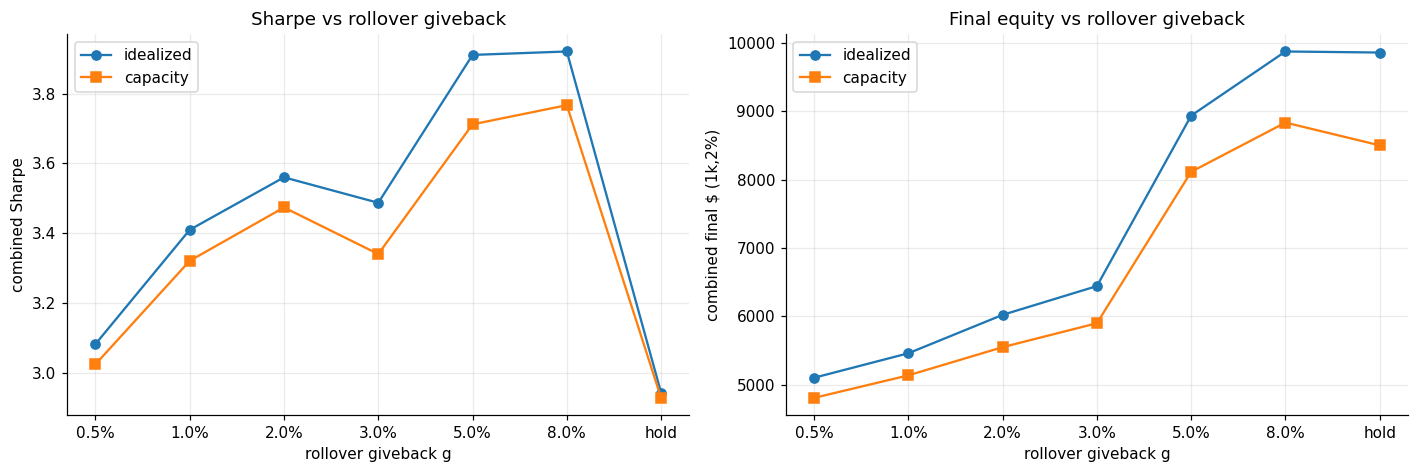

In [5]:
import matplotlib.pyplot as plt
xi=np.arange(len(R)); xt=R.giveback.values
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.4))
a1.plot(xi,R.ideal_S,"o-",label="idealized"); a1.plot(xi,R.cap_S,"s-",label="capacity")
a1.set_xticks(xi); a1.set_xticklabels(xt); a1.set_xlabel("rollover giveback g"); a1.set_ylabel("combined Sharpe")
a1.set_title("Sharpe vs rollover giveback"); a1.legend()
a2.plot(xi,R.ideal_fin,"o-",label="idealized"); a2.plot(xi,R.cap_fin,"s-",label="capacity")
a2.set_xticks(xi); a2.set_xticklabels(xt); a2.set_xlabel("rollover giveback g"); a2.set_ylabel("combined final $ (1k,2%)")
a2.set_title("Final equity vs rollover giveback"); a2.legend()
show("comb_14_rollover")

## Verdict — rollover exit is REAL (unlike the time-cut): it fixes the pump leg

Where the nb13 time-cut was refuted, the rollover (trailing take-profit) is a genuine,
causal, year-robust improvement — because it targets the right thing (our profit
rolling over) instead of the wrong thing (being underwater early).

**1. The mechanism is real and measured.** Both legs reach their favorable peak well
before the 240-min horizon then give a large chunk back: pump peaks at median minute
73 (mean +4.94%) and by 240 keeps **−4% of that peak** (i.e. round-trips into a loss,
hold mean −0.20%); dump peaks ~105 min (+10%) and keeps **49%**. Holding to a fixed
horizon round-trips the reversion. The trailing exit captures the peak.

**2. Per-trade, risk-adjusted edge improves on BOTH legs** (opposite of the time-cut).
Pump mean/std flips from −0.03 (hold) to +0.10 (g=0.5%); dump from +0.36 to +0.49.
Pump's raw mean flips from negative to positive. worst trade improves (pump −39→−35%,
dump −38→−24%) because rollover often exits a faded winner before a later crash leg.

**3. Year-split confirms robustness — the pump fix holds every year.** Pump mean/trade
at g=2%: 2024 +0.15% (hold −0.17%), 2025 +0.50% (hold −0.39%), 2026 +0.41% (hold
+0.34%). In every year tight rollover turns the dead/negative pump leg positive. Dump
keeps the highest raw mean by holding in every year (rollover trades return for lower
variance) — so rollover is a *risk* tool for dump, an *edge* tool for pump.

**4. Portfolio: a Pareto improvement, and NOT a turnover/single-cluster artifact.**
Combined ($1k, 2%, capacity model): hold → Sharpe 2.93, DD −14.5%, $8,502. At
**g=8%**: Sharpe **3.77**, DD **−9.3%**, **$8,836** — higher Sharpe, lower drawdown,
and the *same* final money. Sharpe rises smoothly across the sweep (no flat-then-jump),
and the DD improves at every g (broad variance reduction, not one clipped crash day).
The turnover artifact that flattered nb13 is ruled out here: tighter g = far faster
turnover (hold 244→21 min) but *lower* Sharpe/final, while the optimum sits at moderate
g=5–8% where hold time is barely shortened (200–156 min) — so the gain is the captured
reversion, not compounding-via-recycling.

**Which giveback.** The legs disagree: pump wants TIGHT (~2%, that's what flips it
positive) while dump wants WIDE/hold (its edge is in the slow bounce). The single
combined optimum g≈5–8% is a compromise. **The obvious refinement: a per-leg giveback
— tight (~2%) on pump, wide (~8%) or hold on dump.** That should beat any single g.

**Recommendation: adopt a rollover (trailing take-profit) exit — most importantly on
the pump leg, where it converts a leg that was net-zero/negative under a fixed horizon
into a positive contributor.** This is a real edge improvement, causally grounded
(reversion peaks early then decays, verified every year), and it lowers drawdown.

Caveats: tight g (≤2%) exits on small wiggles → most exposed to fill slippage/
microstructure (the 0.1% slip is modeled but 1-min bars can't fully adjudicate); the
robust optimum at g=5–8% / 150–200-min holds is far less slippage-sensitive. Each g
retrains its own WF classifier (kept-sets differ slightly). In-sample 2024–26, idealized
+ estimated-capacity engine, no live confirmation. Next: per-leg giveback; then
slippage-sensitivity on the tight-g pump exit.